In [2]:
import urllib.request
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download directly from official GitHub repository data sources
github_url = "https://github.com/lerocha/chinook-database/raw/master/ChinookDatabase/DataSources/Chinook_Sqlite.sqlite"
headers = {'User-Agent': 'Mozilla/5.0'}
req = urllib.request.Request(github_url, headers=headers)

print("Fetching the database directly from GitHub...")
with urllib.request.urlopen(req) as response, open("chinook.db", "wb") as out_file:
    out_file.write(response.read())

# 2. Establish a clean connection to the downloaded database file
conn = sqlite3.connect('chinook.db')
print("\n🎉 Success! Connected cleanly to the populated Chinook database.")


Fetching the database directly from GitHub...

🎉 Success! Connected cleanly to the populated Chinook database.


In [3]:
# Display all tables within the database schema
tables = pd.read_sql_query("SELECT name FROM sqlite_master WHERE type='table';", conn)
tables


,name
0,Album
1,Artist
2,Customer
3,Employee
4,Genre
5,Invoice
6,InvoiceLine
7,MediaType
8,Playlist
9,PlaylistTrack


In [4]:
q1 = """
SELECT t.Name AS TrackName, SUM(il.Quantity) AS TotalSold
FROM InvoiceLine il
JOIN Track t ON il.TrackId = t.TrackId
GROUP BY il.TrackId
ORDER BY TotalSold DESC
LIMIT 10;
"""
top_tracks = pd.read_sql_query(q1, conn)
top_tracks.index = top_tracks.index + 1  # 1-based index adjustment
top_tracks


,TrackName,TotalSold
1,Balls to the Wall,2
2,Inject The Venom,2
3,Snowballed,2
4,Overdose,2
5,Deuces Are Wild,2
6,Not The Doctor,2
7,Por Causa De Você,2
8,Welcome Home (Sanitarium),2
9,Snowblind,2
10,Cornucopia,2


In [5]:
q2 = """
SELECT BillingCountry AS Country, ROUND(SUM(Total), 2) AS TotalRevenue
FROM Invoice
GROUP BY BillingCountry
ORDER BY TotalRevenue DESC;
"""
country_revenue = pd.read_sql_query(q2, conn)
country_revenue.index = country_revenue.index + 1  # 1-based index adjustment
country_revenue.head(5)


,Country,TotalRevenue
1,USA,523.06
2,Canada,303.96
3,France,195.10
4,Brazil,190.10
5,Germany,156.48


In [6]:
q3 = """
SELECT e.FirstName || ' ' || e.LastName AS EmployeeName, ROUND(SUM(i.Total), 2) AS TotalSales
FROM Employee e
JOIN Customer c ON e.EmployeeId = c.SupportRepId
JOIN Invoice i ON c.CustomerId = i.CustomerId
GROUP BY e.EmployeeId
ORDER BY TotalSales DESC;
"""
top_employees = pd.read_sql_query(q3, conn)
top_employees.index = top_employees.index + 1  # 1-based index adjustment
top_employees


,EmployeeName,TotalSales
1,Jane Peacock,833.04
2,Margaret Park,775.40
3,Steve Johnson,720.16


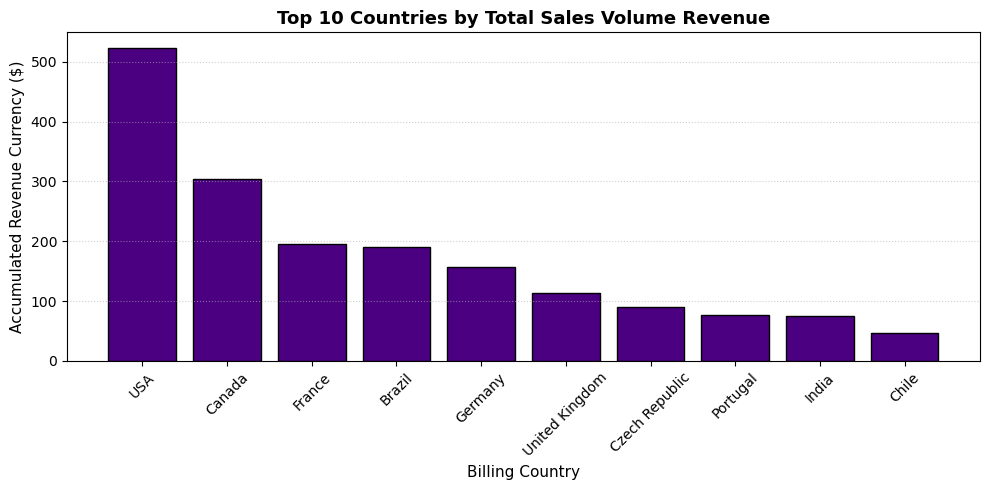

In [7]:
# Isolate top 10 country records for chart mapping
chart_data = country_revenue.head(10)

plt.figure(figsize=(10, 5))
plt.bar(chart_data['Country'], chart_data['TotalRevenue'], color='indigo', edgecolor='black')

# Labeling and styling alignment setups
plt.title('Top 10 Countries by Total Sales Volume Revenue', fontsize=13, fontweight='bold')
plt.xlabel('Billing Country', fontsize=11)
plt.ylabel('Accumulated Revenue Currency ($)', fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [8]:
conn.close()
print("Database session safely disconnected.")


Database session safely disconnected.


In [9]:
# Create a .gitignore file to exclude the database and large zip archives from GitHub
with open(".gitignore", "w") as f:
    f.write("chinook.db\n")
    f.write("chinook.zip\n")

print(".gitignore successfully configured to hide database files from tracking!")


.gitignore successfully configured to hide database files from tracking!


In [10]:
readme_text = """# Querying with SQL & Python (Chinook Digital Music Store Analysis)

## 📌 Project Overview
This data analytics project leverages Python, SQLite, and Pandas to interrogate the relational database structure of the fictional **Chinook Digital Music Store**. The objective is to unpack complex business entities, execute database joins, analyze sales volumes, and compile structural reporting matrices directly from an internal `sqlite3` data connection.

## 🛠️ Technology Stack
* **Environment:** Anaconda Navigator / Jupyter Notebook (Python 3)
* **Core Engine:** SQLite (`sqlite3`)
* **Data Processing:** Pandas
* **Data Visualization:** Matplotlib

## 🔍 Core Analytical Discoveries
The operational workflow answered three key operational queries using targeted SQL operations:
1. **Top 10 Best-Selling Tracks:** Extracted and ordered via aggregated track IDs and transactional purchase lines.
2. **Global Revenue Contributions:** Categorized and aggregated financial metrics across global billing destinations.
3. **Top Performing Sales Representative:** Multi-table customer and employee relational metrics aggregated by gross total transactional volume.

*Note: DataFrames are outputted using clean, human-readable 1-based indexing.*

## 💾 Project Artifacts Produced
* `Untitled.ipynb`: The complete execution notebook containing database queries and code logic.
* `Chinook_Top_Country_Revenue_Summary.csv`: Aggregated global sales distribution dataset.
"""

# Write the contents directly to a file in your project folder
with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme_text)

print("README.md file successfully generated in your project folder!")


README.md file successfully generated in your project folder!
